# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [44]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = ''

## TO DO: read_csv()
df = pd.read_csv('airline_2019.csv', usecols=use_cols)

## Check the shape of the loaded data
df.shape

(76616, 29)

#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis

In [45]:
## 1.1 Rename a few columns
df = df.rename(columns={
    'Reporting_Airline': 'UniqueCarrier',
    'Flight_Number_Reporting_Airline': 'FlightNum',
    'Tail_Number': 'TailNum'
})

## 1.2 Random sampling for further analysis
df = df.sample(n=20000)


### 2. Basic EDA

In [46]:
## Print first 5 rows to check how the data looks like
df.head()

,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
41245,2019,8,30,5,AS,N287AK,475,SEA,RNO,1145,...,0.0,115.0,110.0,73.0,564.0,0.0,0.0,0.0,0.0,36.0
74541,2019,8,2,5,OO,N809SK,3617,MSP,DLH,1940,...,0.0,56.0,43.0,26.0,144.0,NaN,NaN,NaN,NaN,NaN
54287,2019,5,8,3,YX,N722YX,3460,RDU,EWR,1030,...,0.0,99.0,85.0,68.0,416.0,NaN,NaN,NaN,NaN,NaN
75936,2019,4,27,6,WN,N7843A,3574,SAN,SFO,910,...,0.0,95.0,85.0,63.0,447.0,NaN,NaN,NaN,NaN,NaN
72900,2019,7,18,4,UA,N57863,1229,HNL,LAX,2130,...,0.0,319.0,308.0,285.0,2556.0,NaN,NaN,NaN,NaN,NaN


In [47]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for numeric columns
    res = pd_frame.describe().transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    #
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res


### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

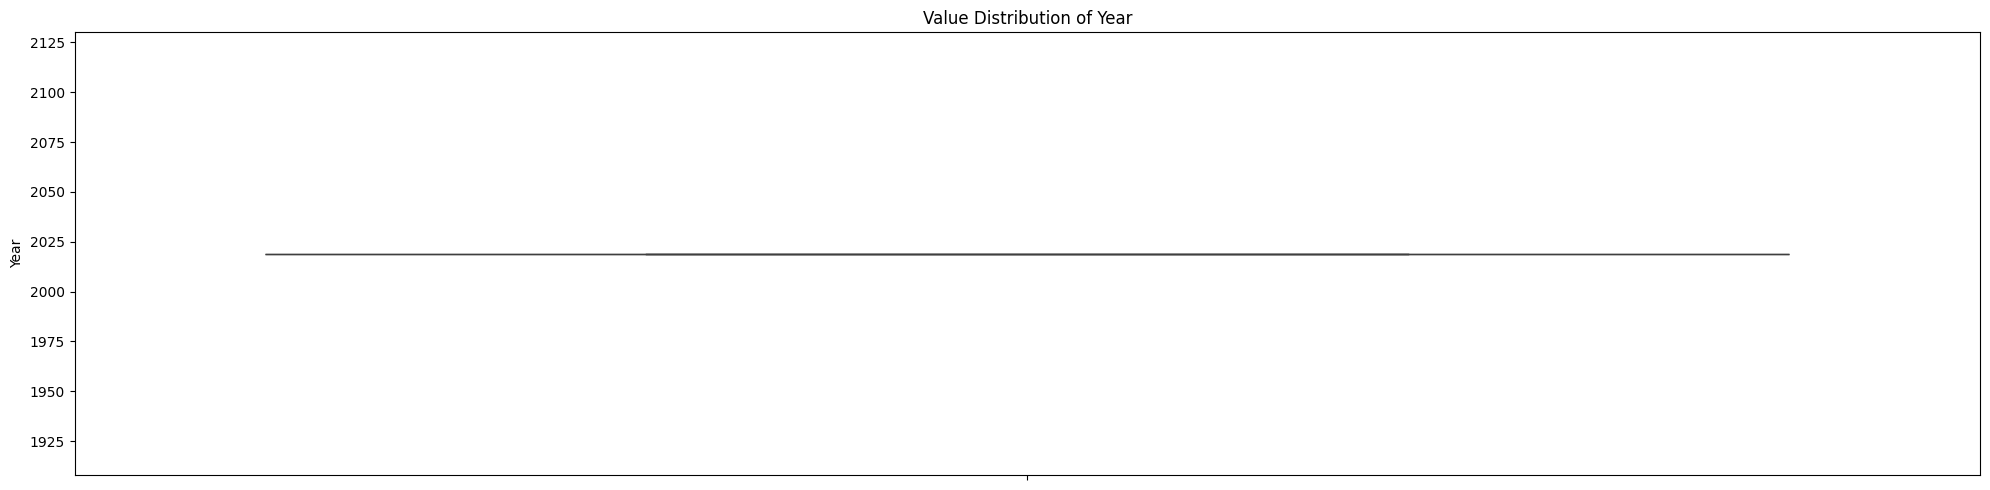

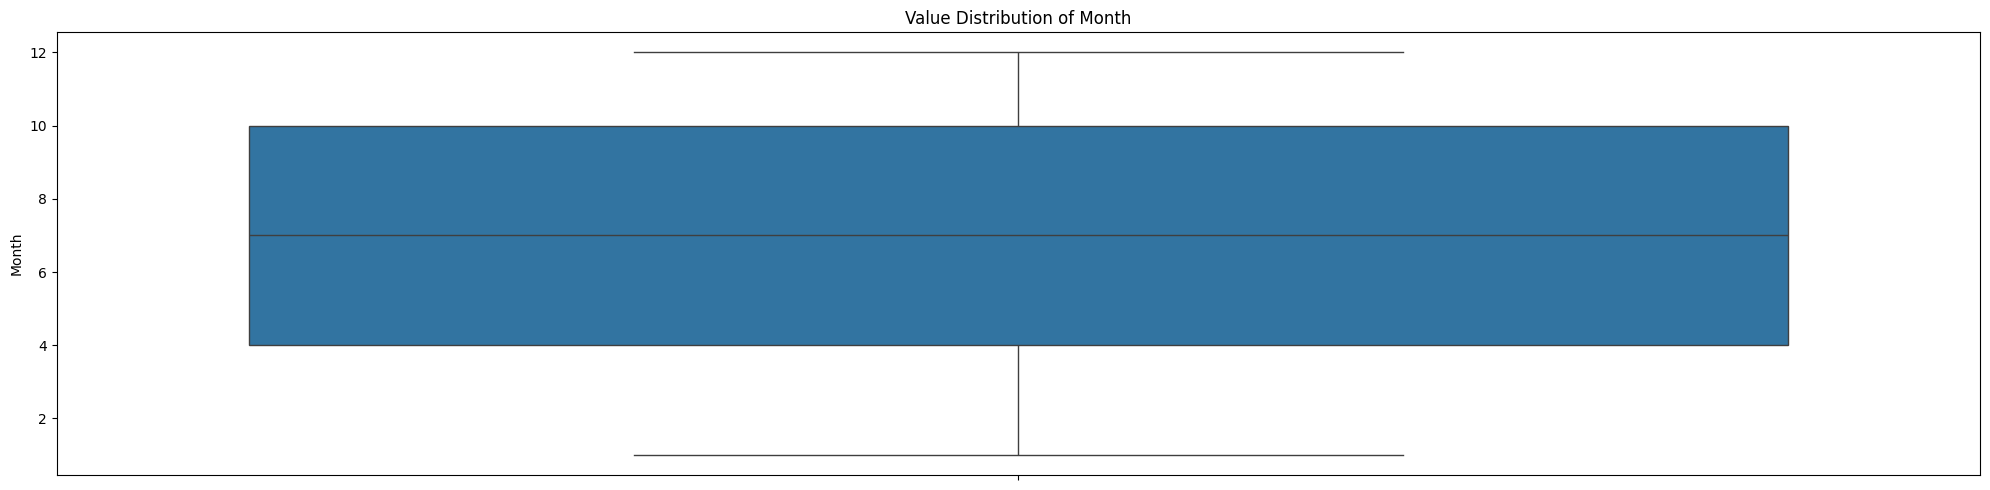

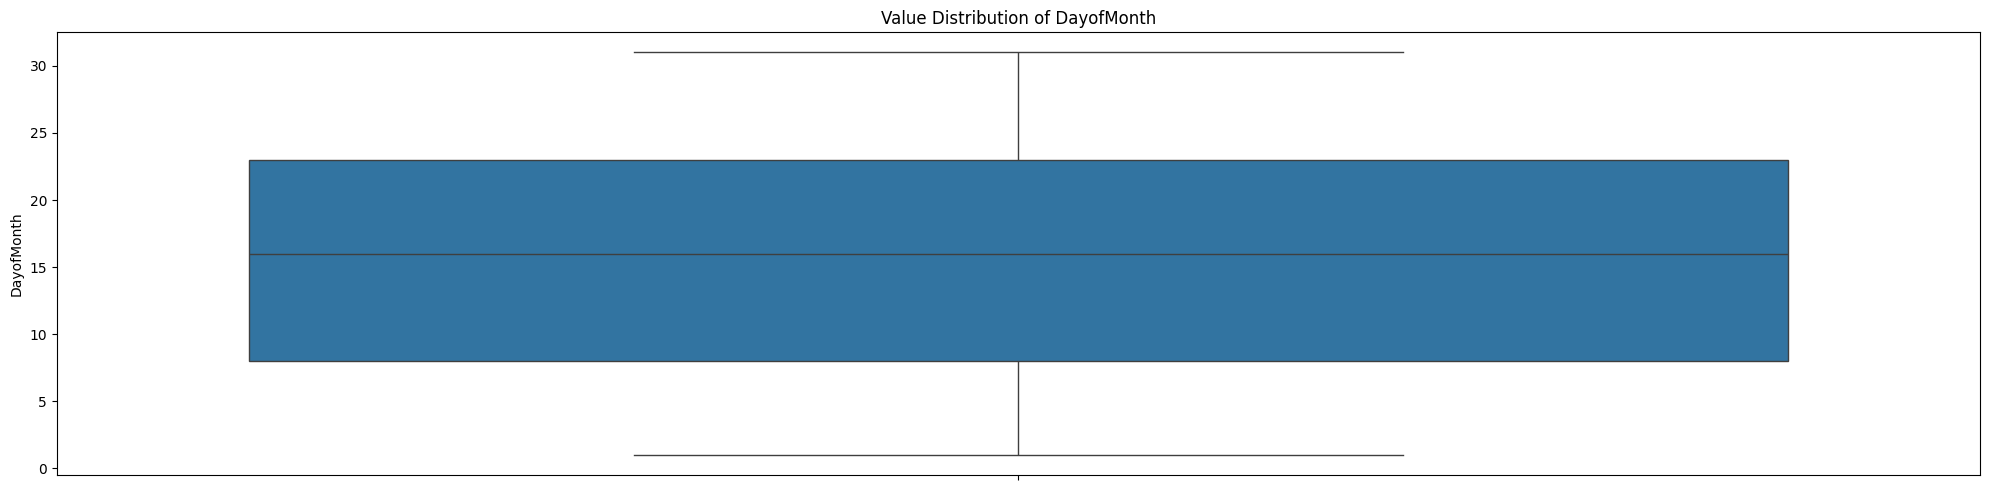

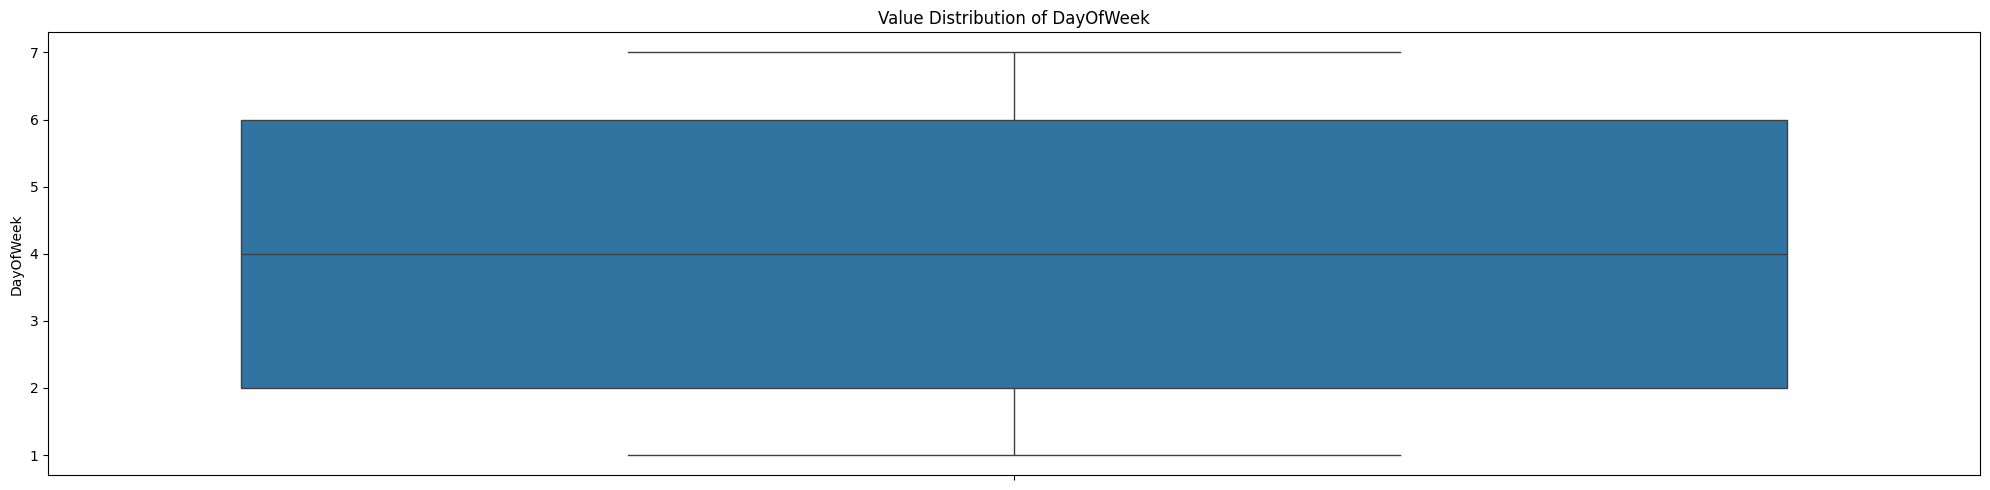

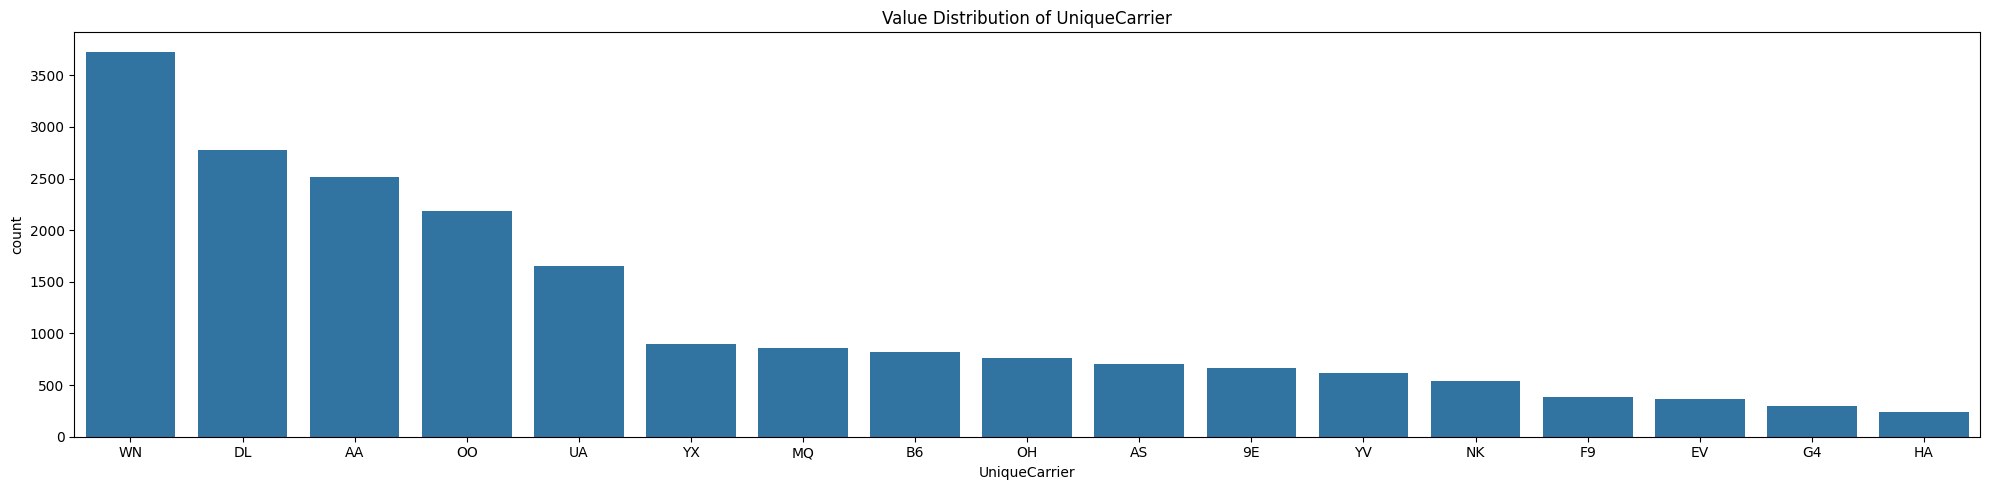

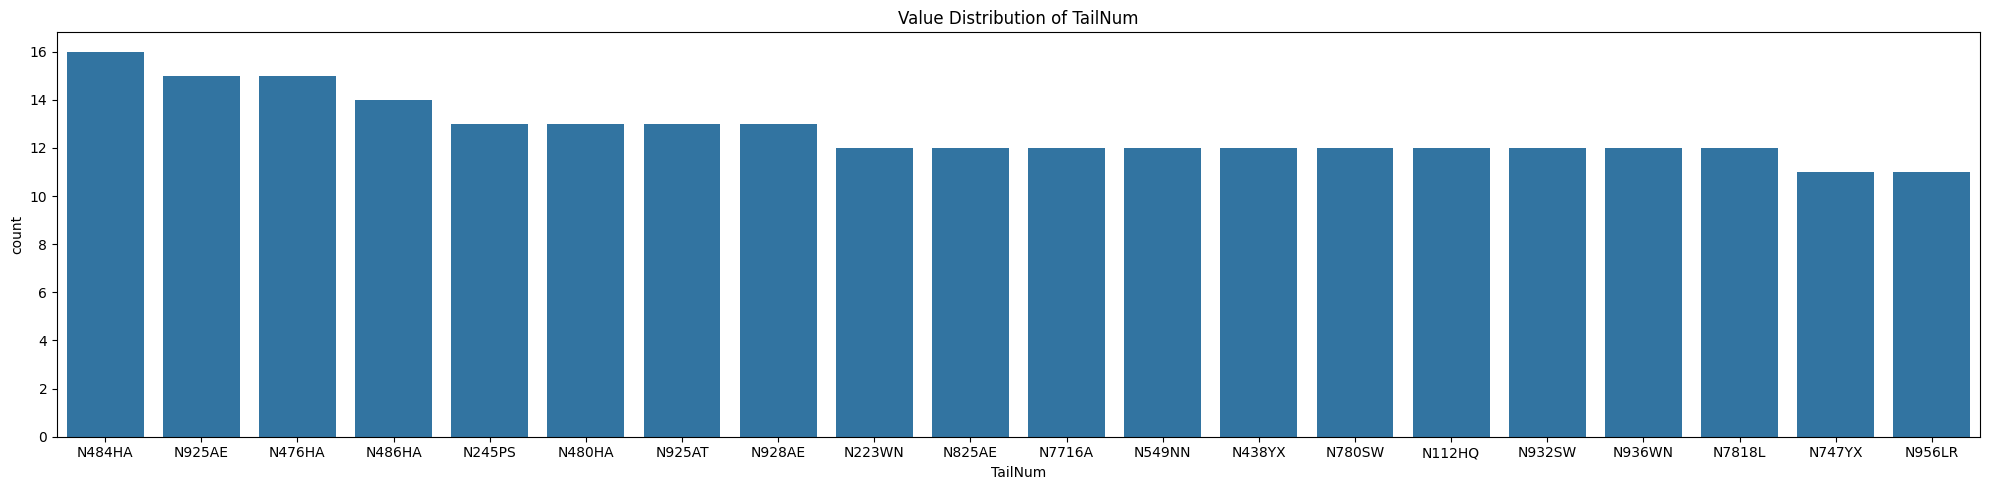

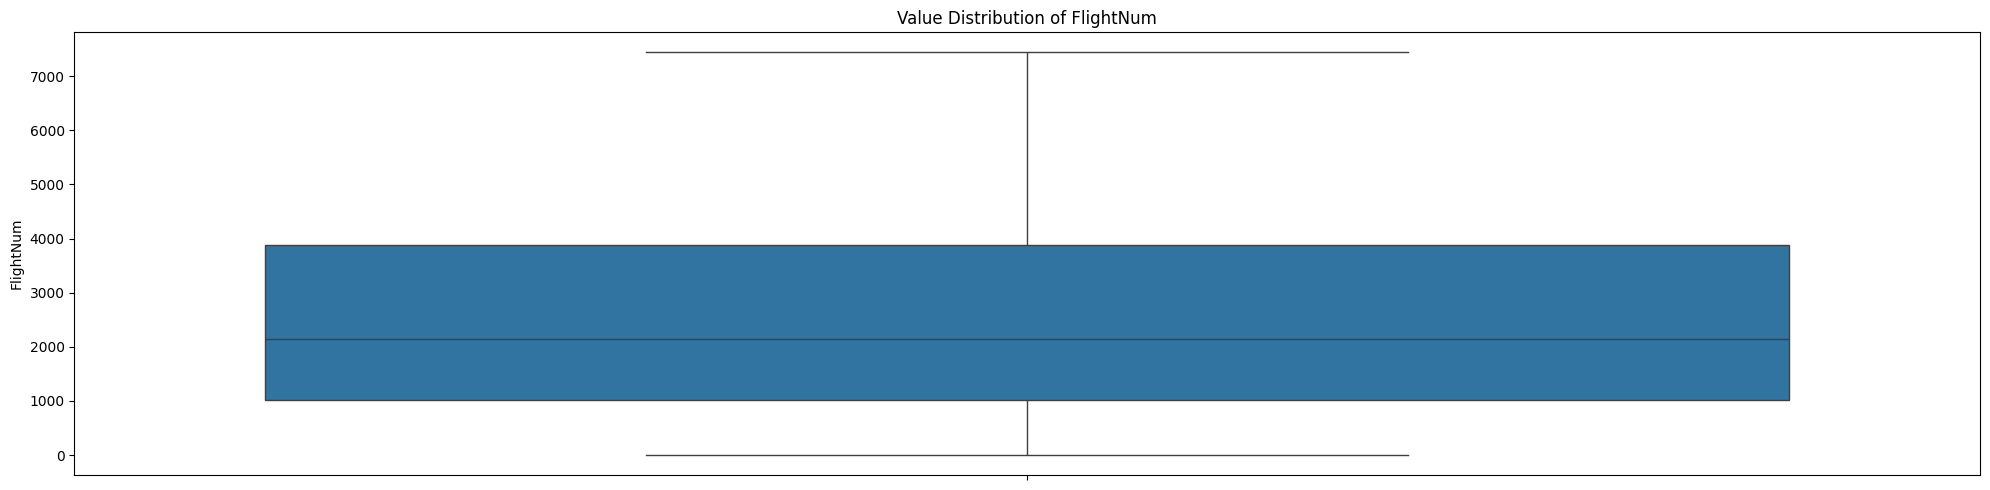

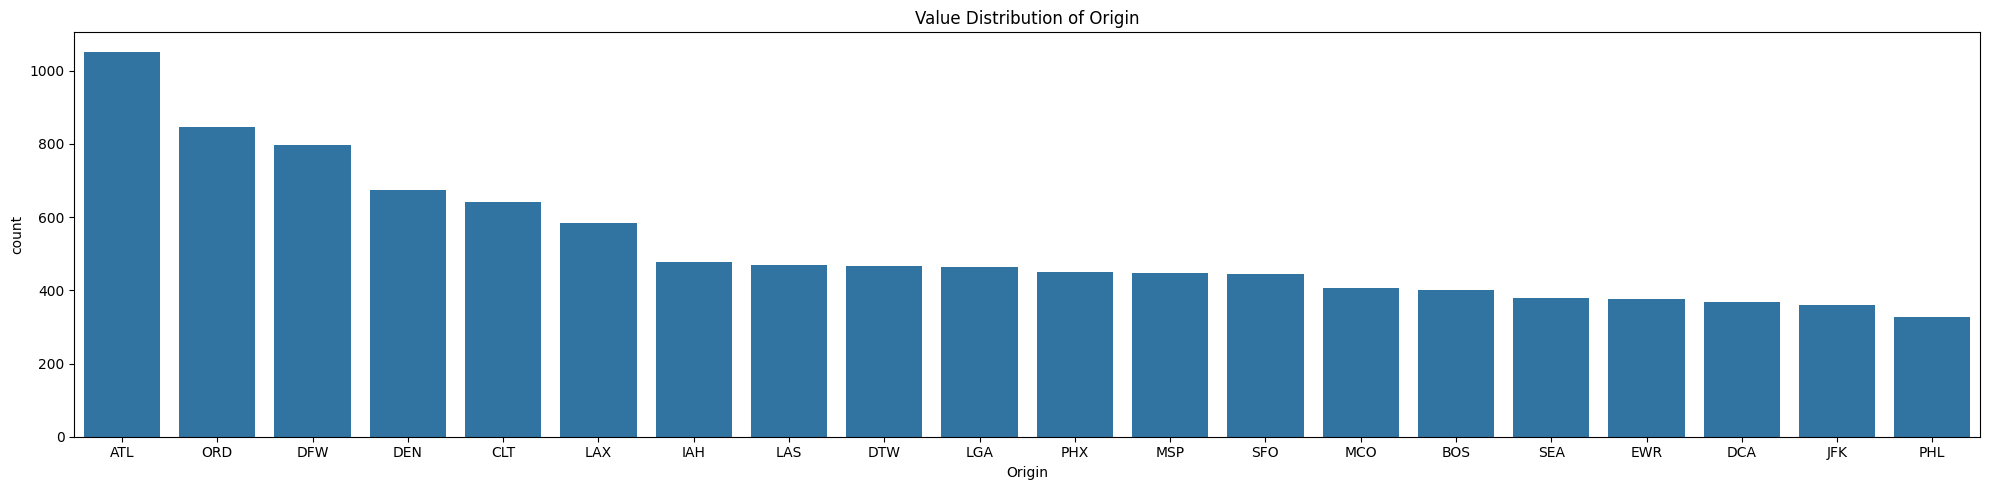

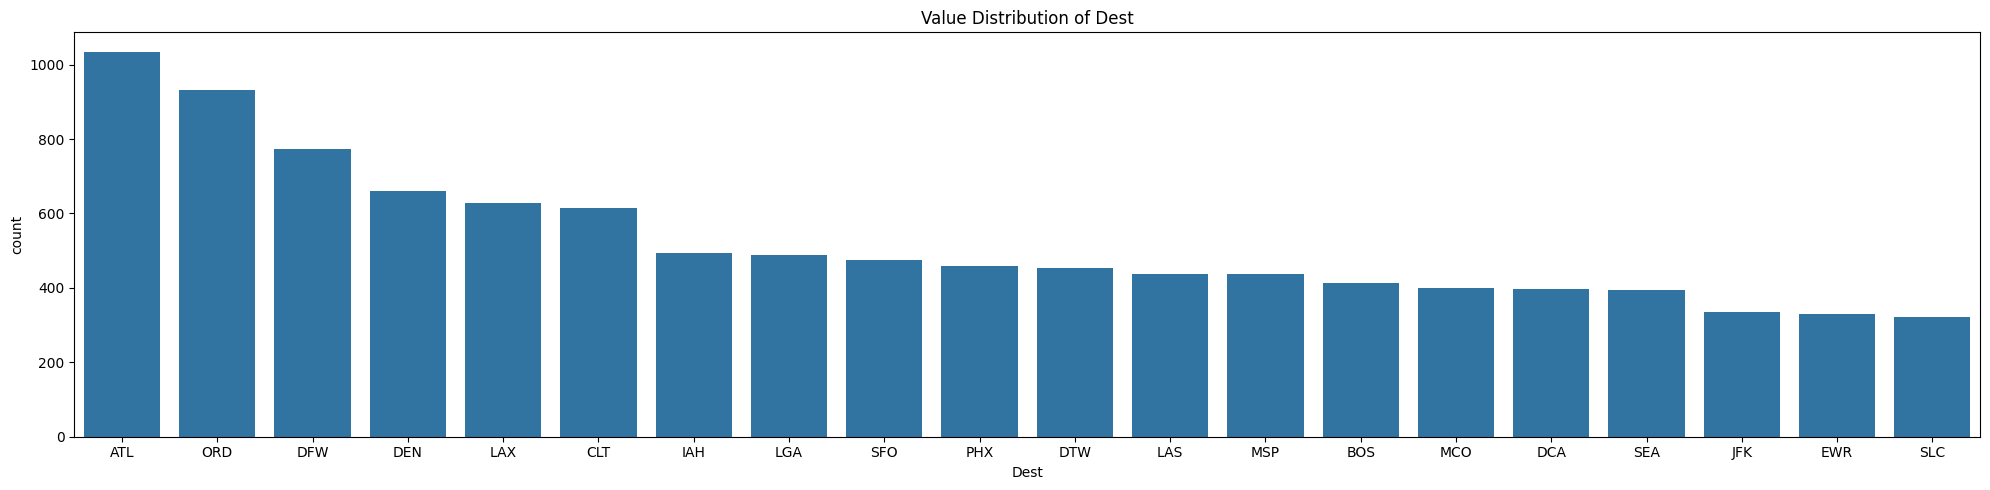

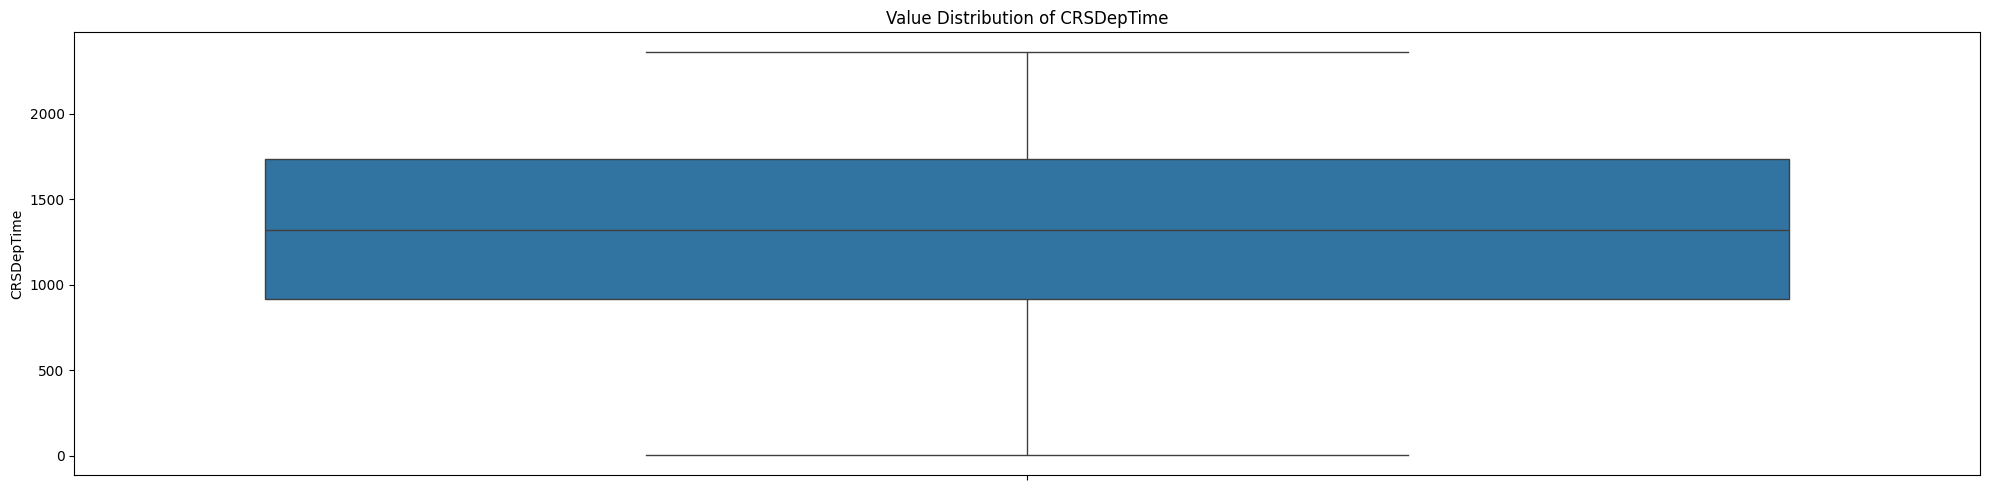

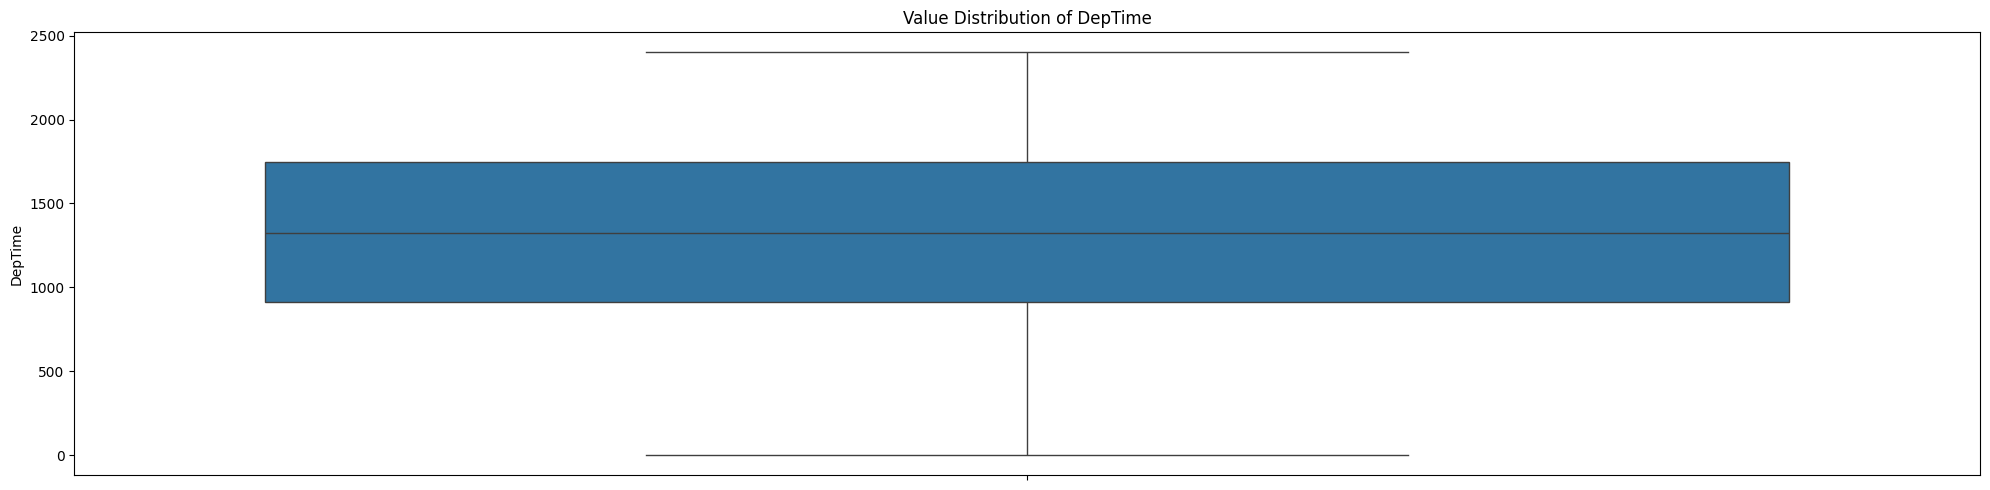

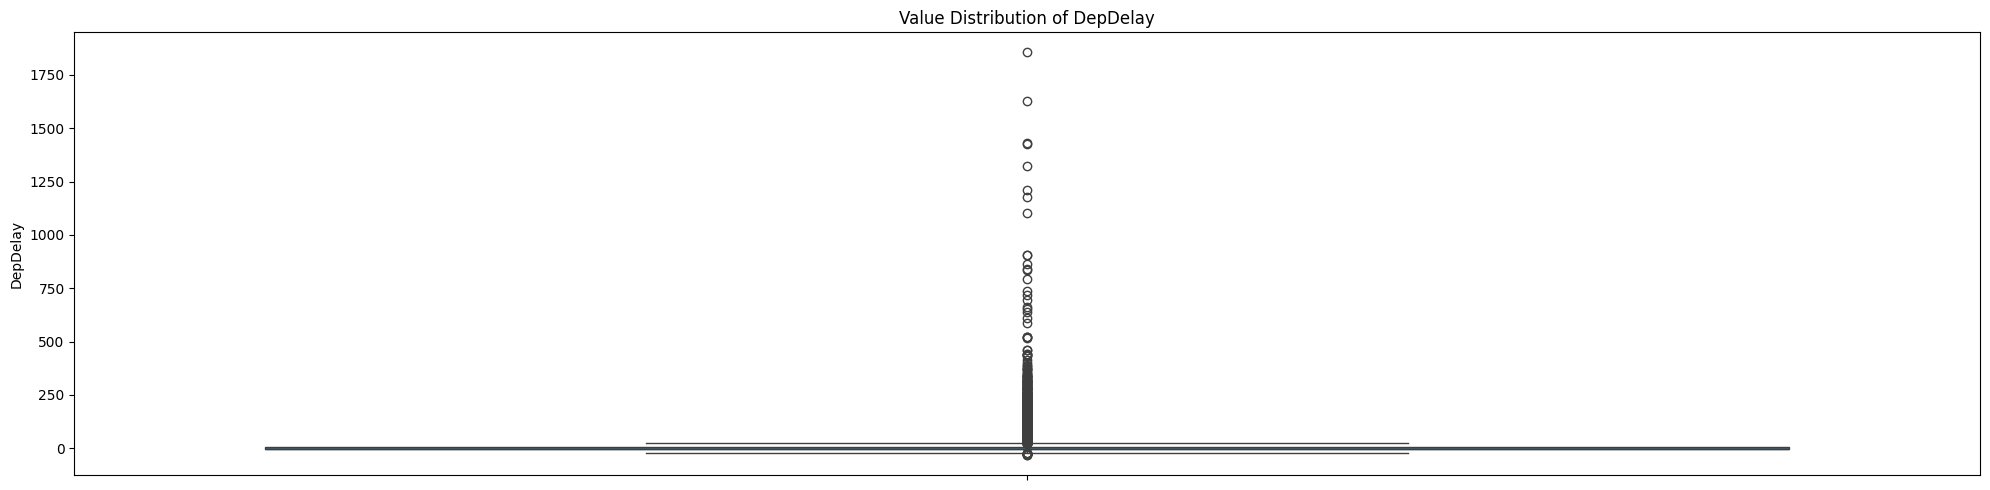

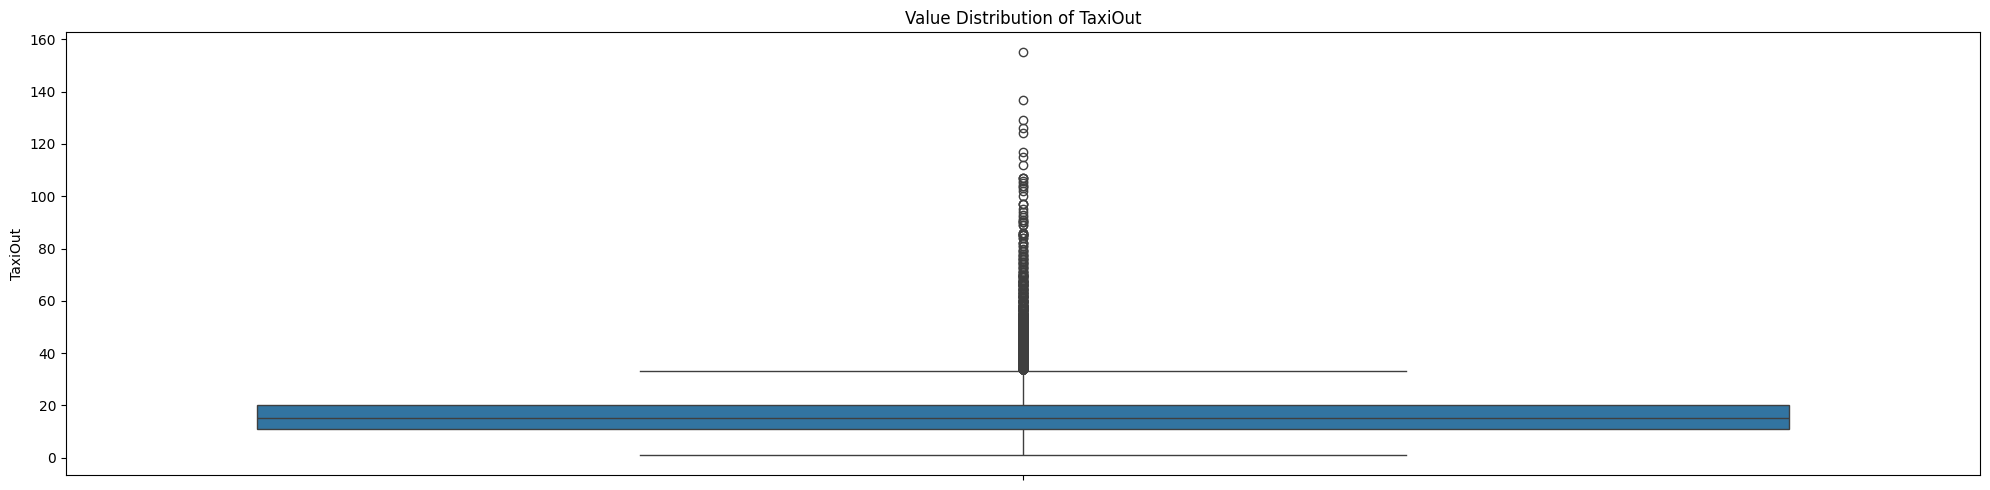

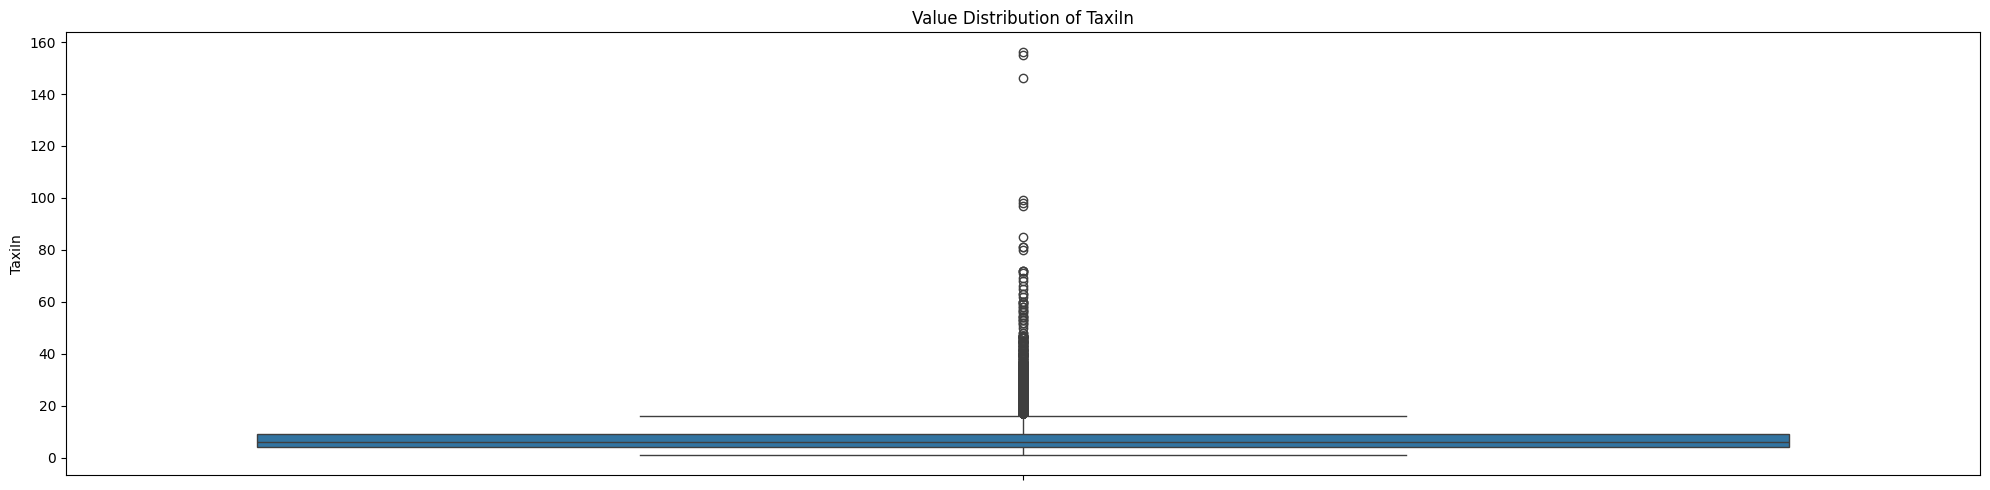

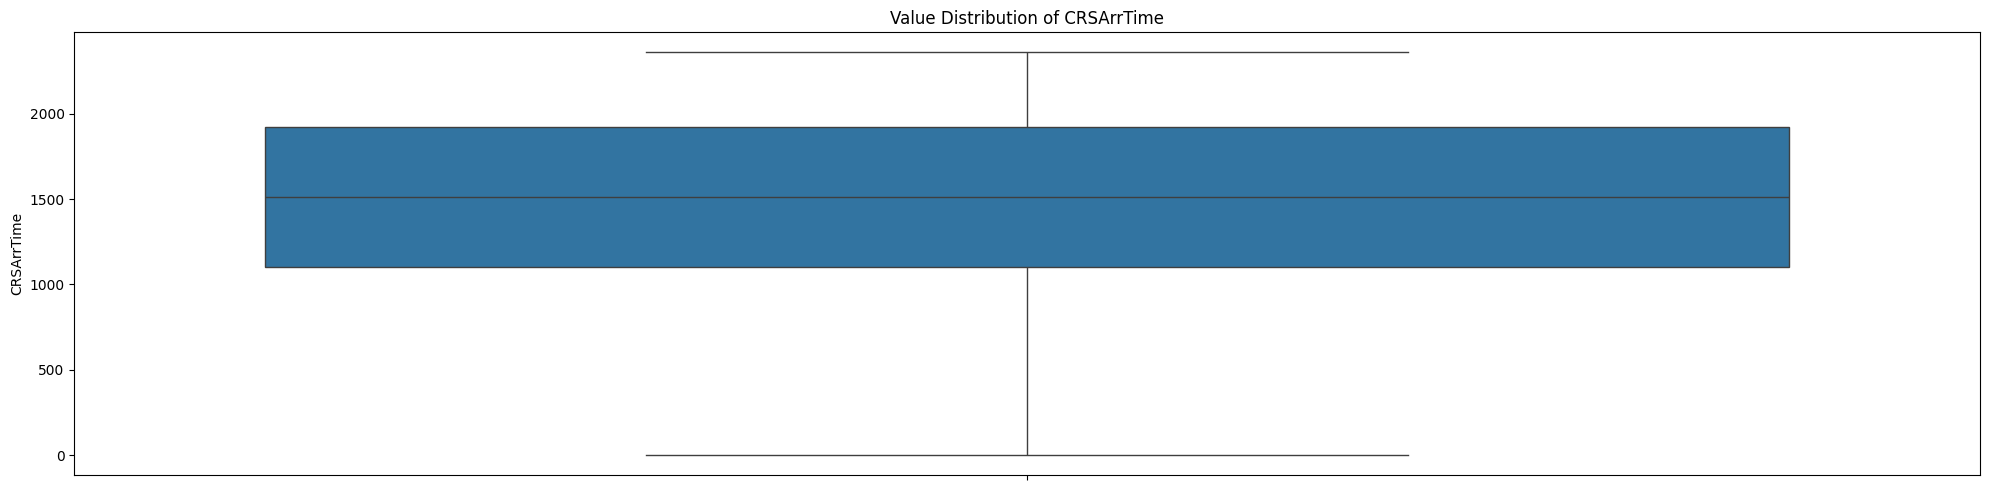

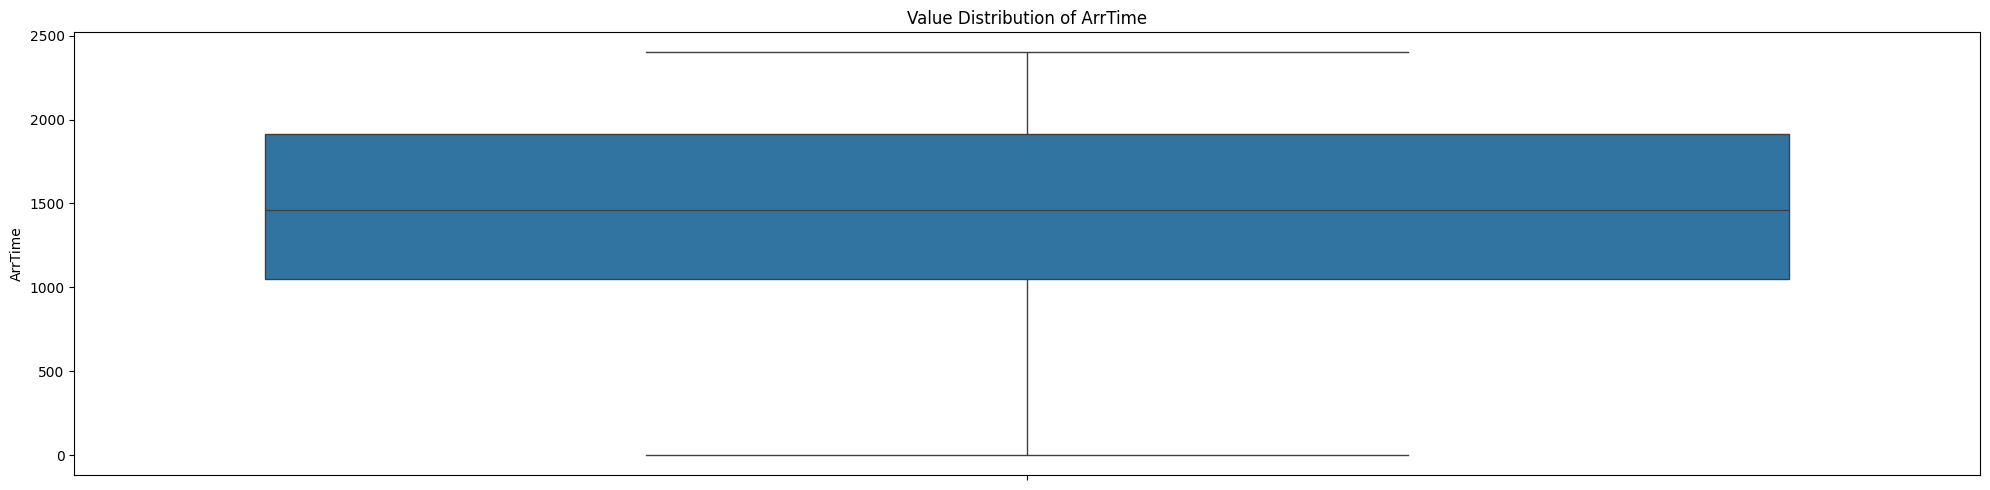

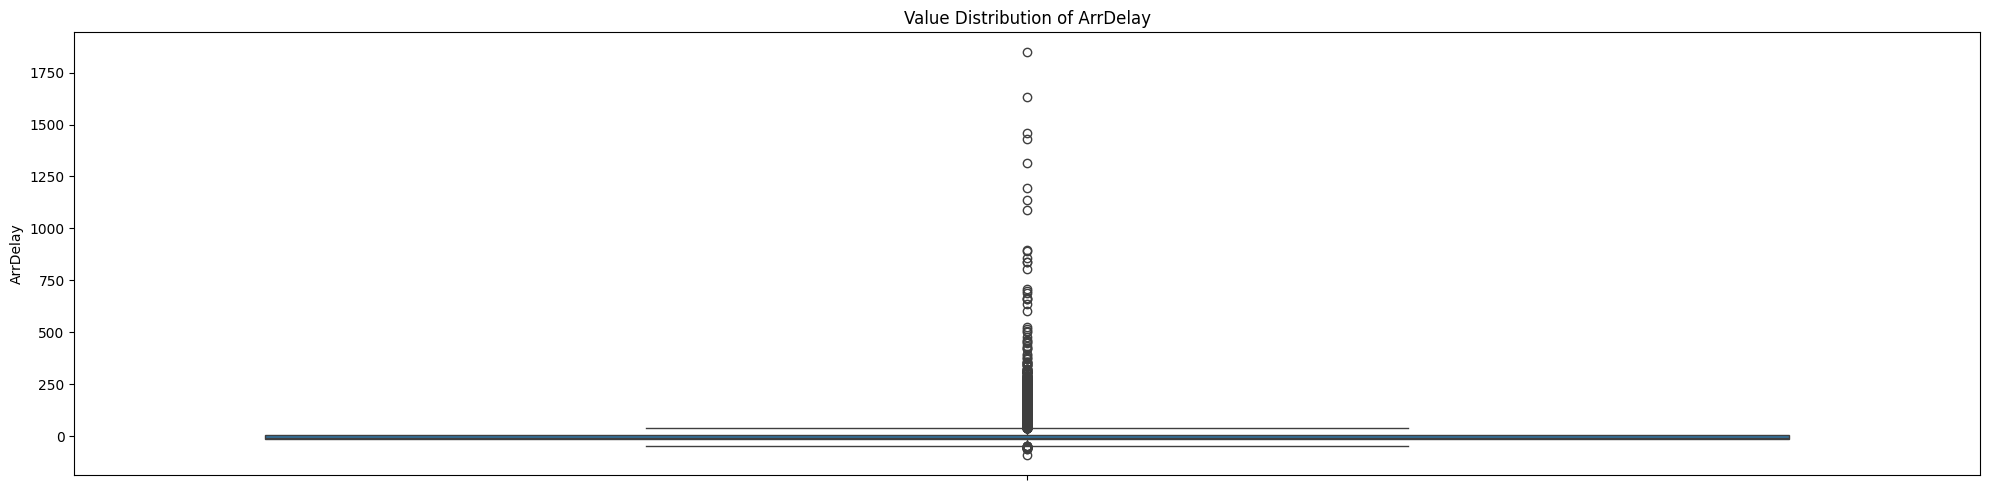

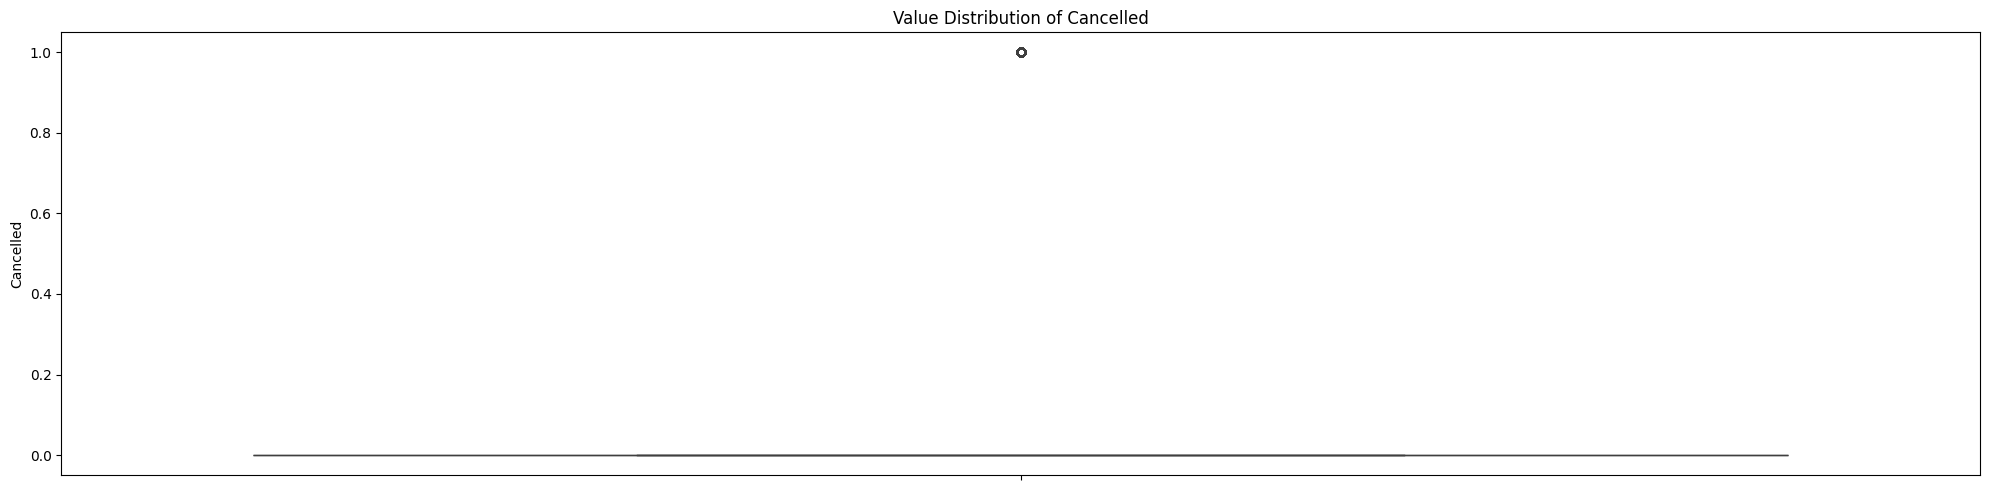

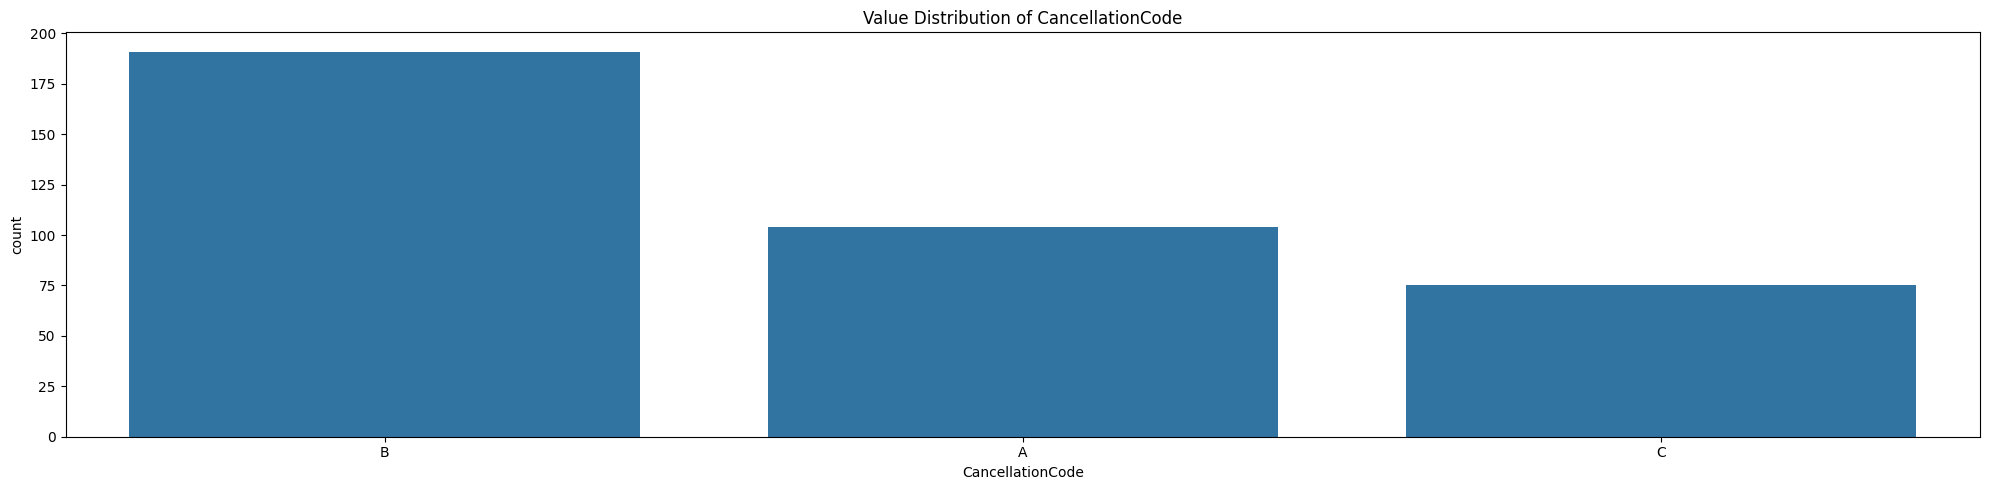

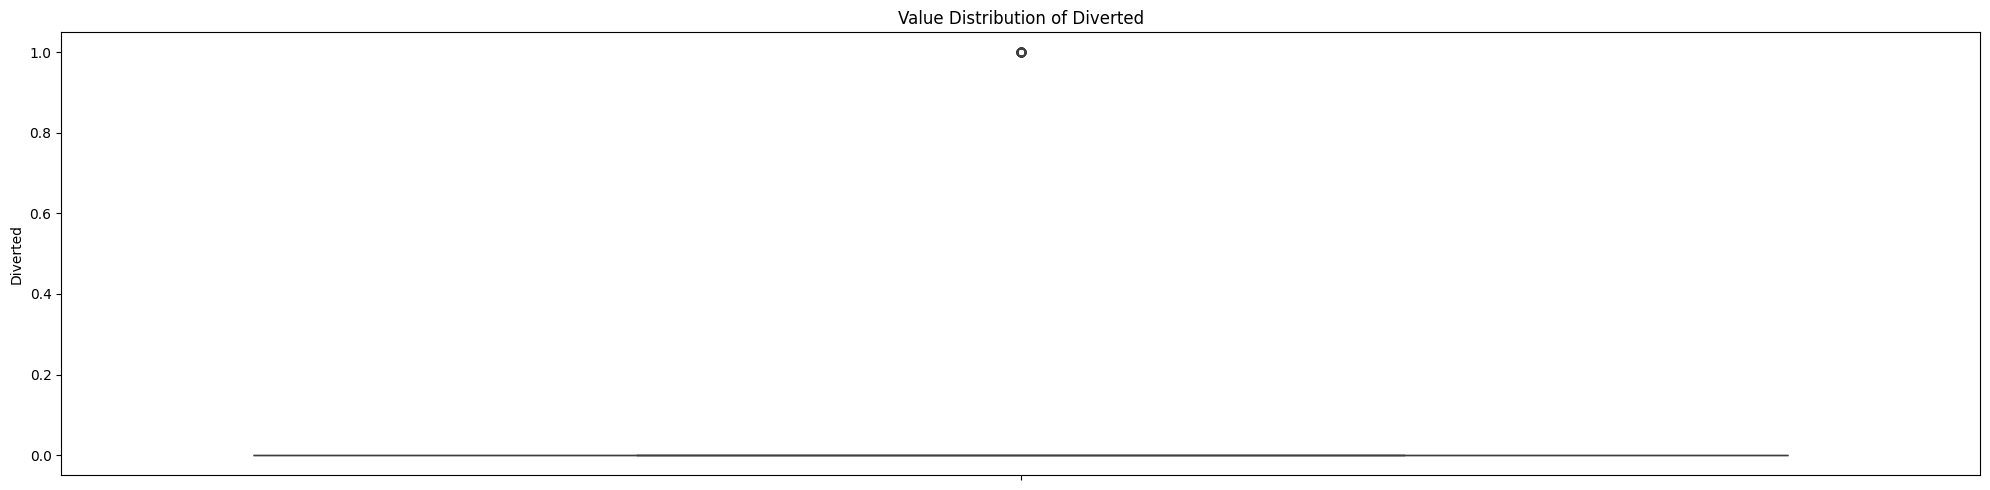

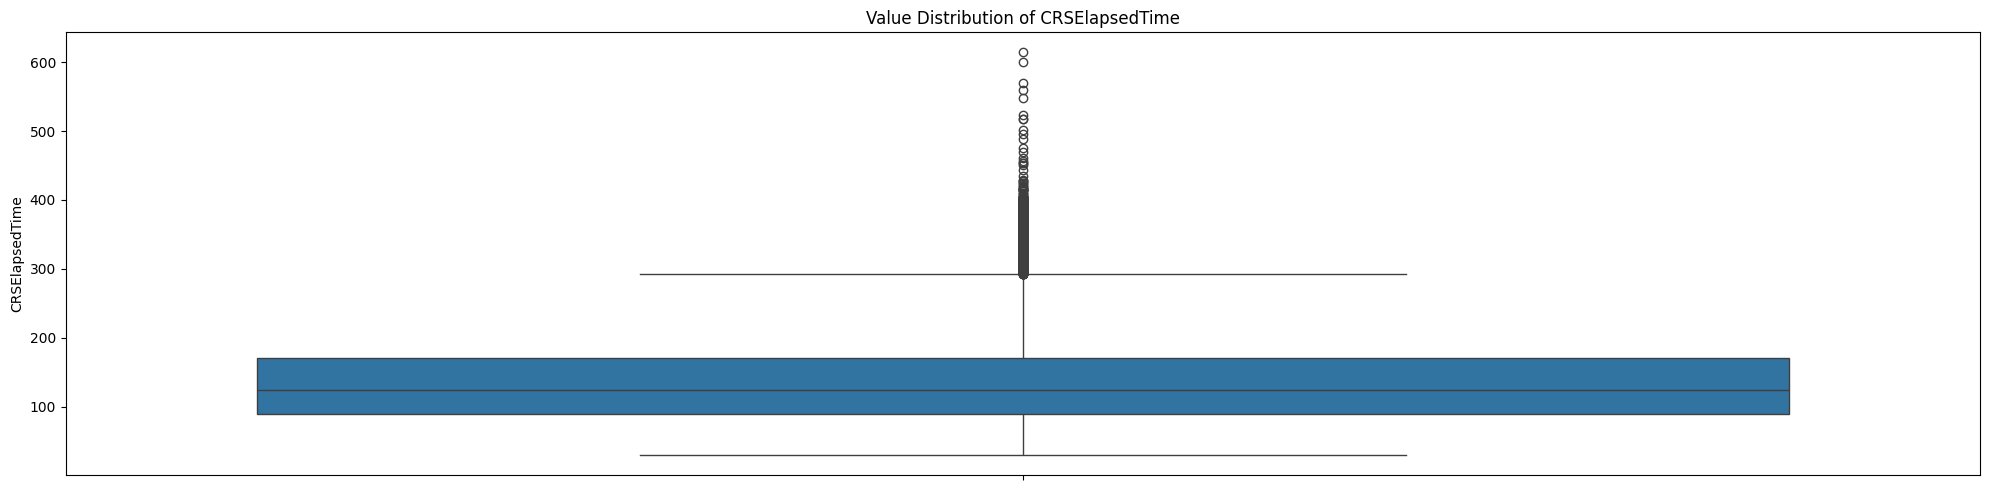

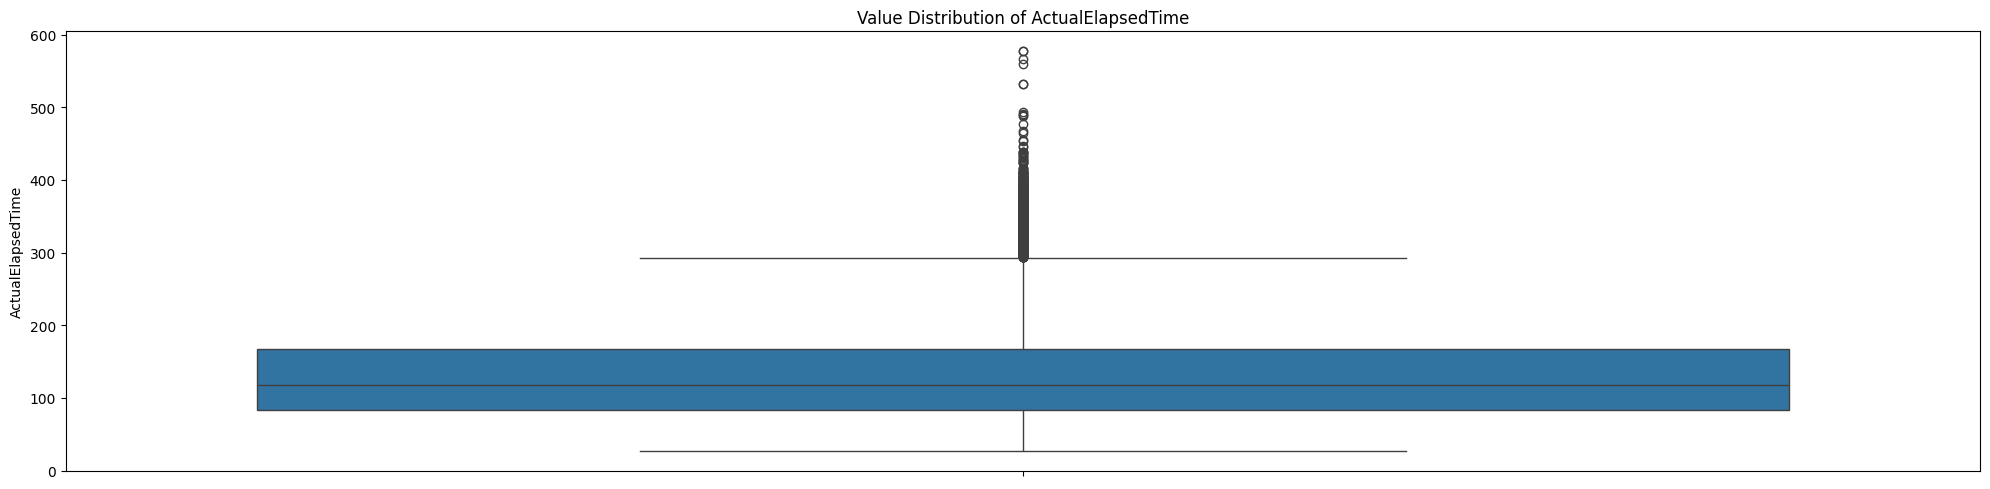

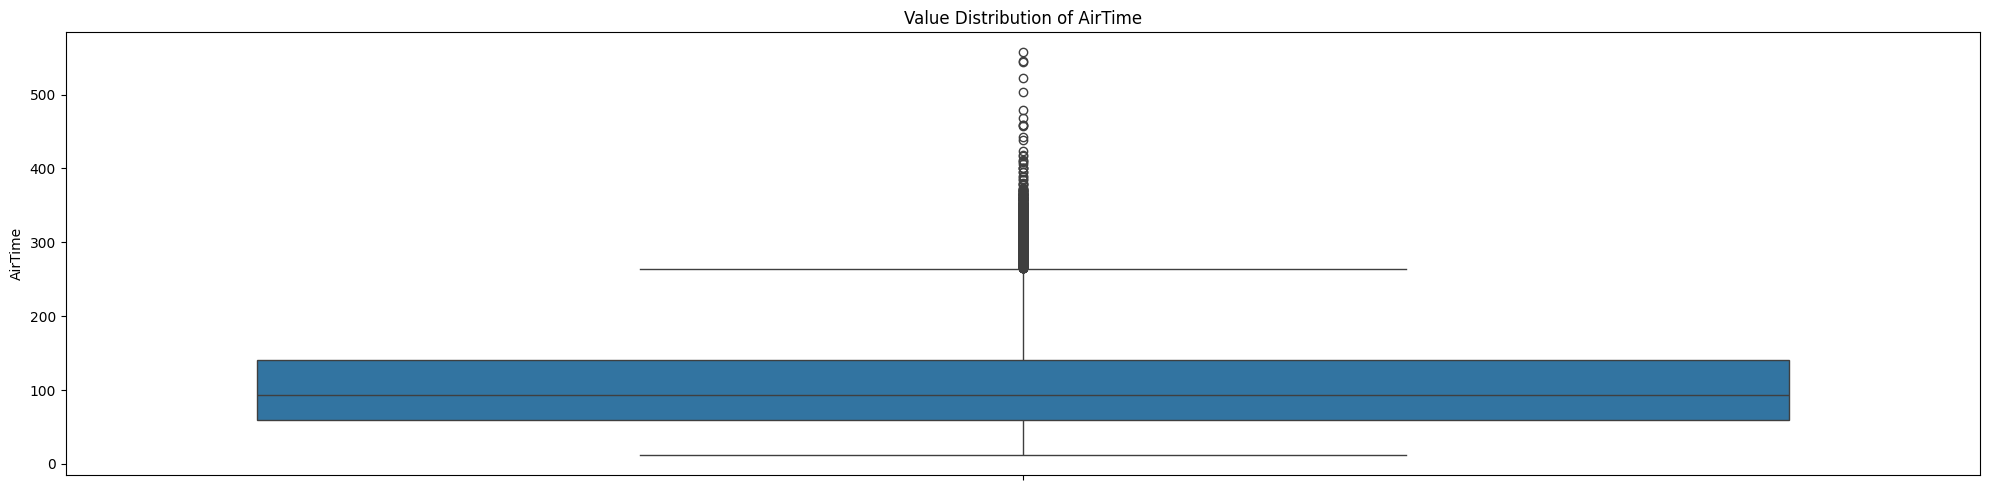

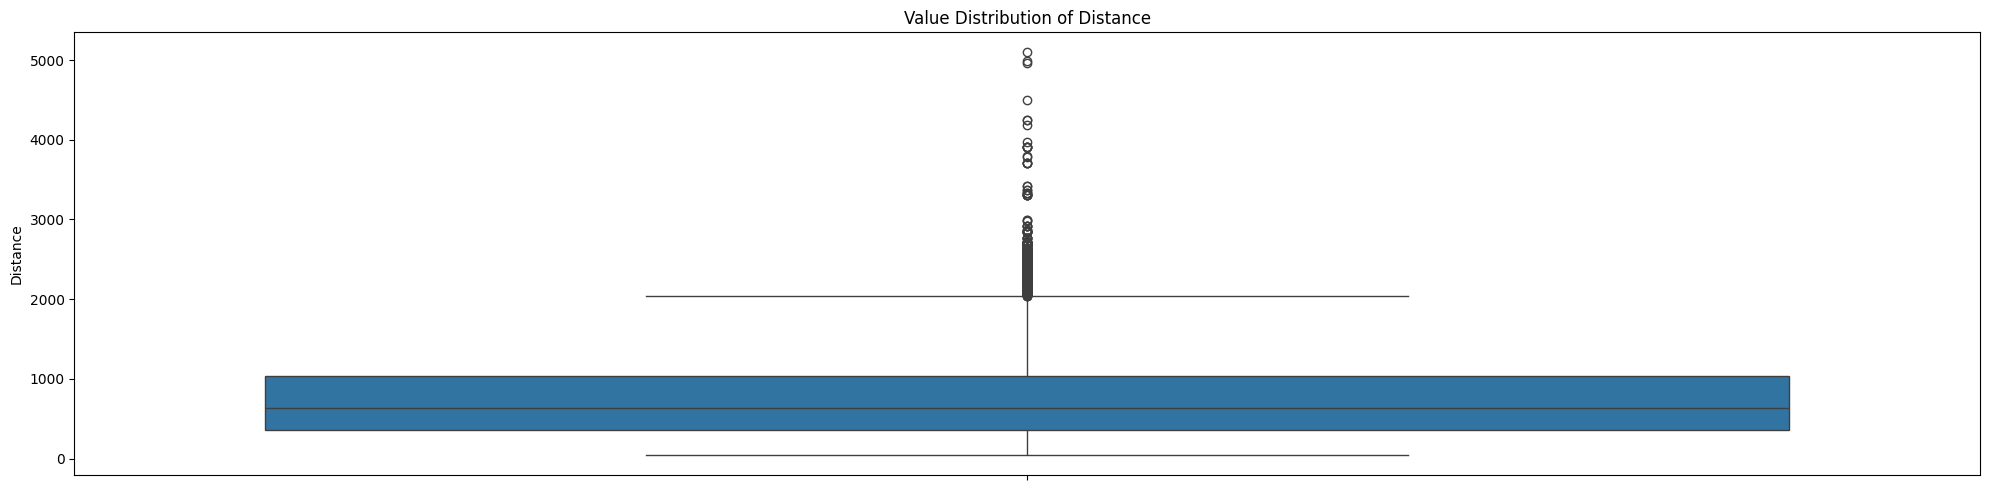

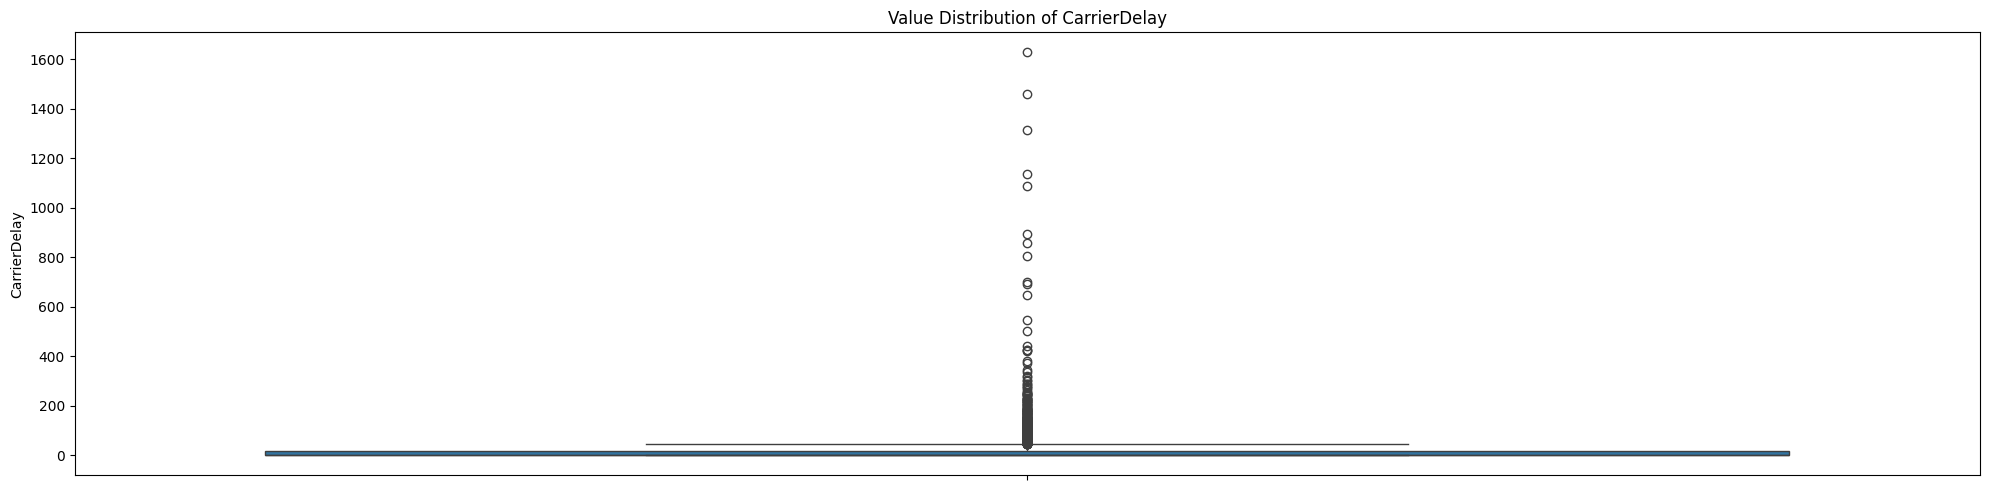

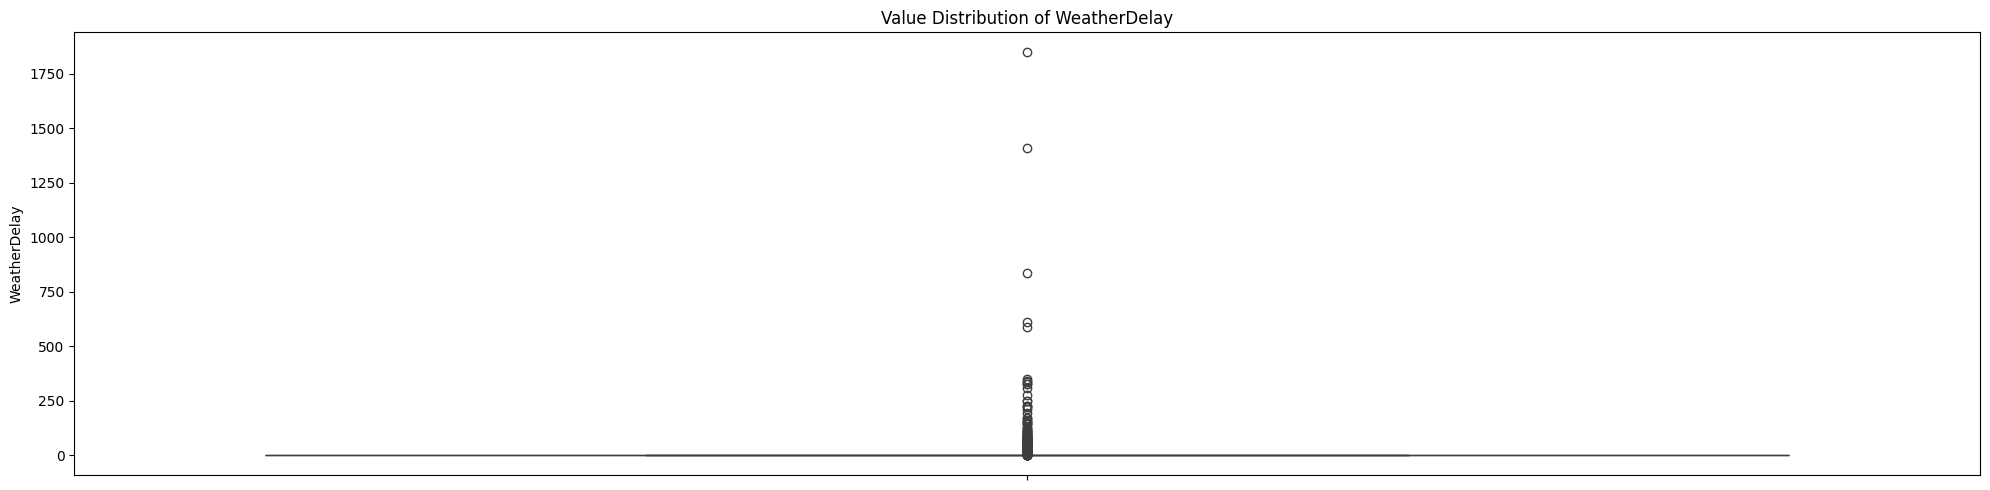

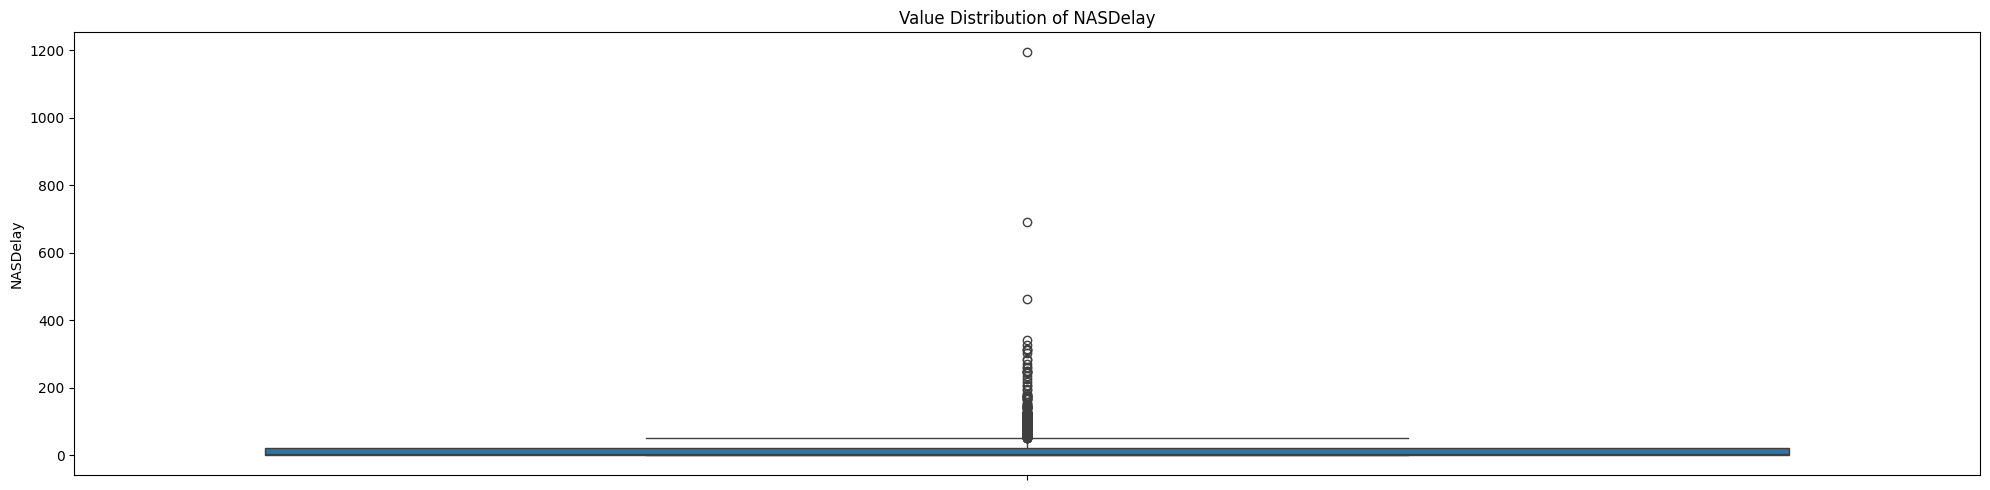

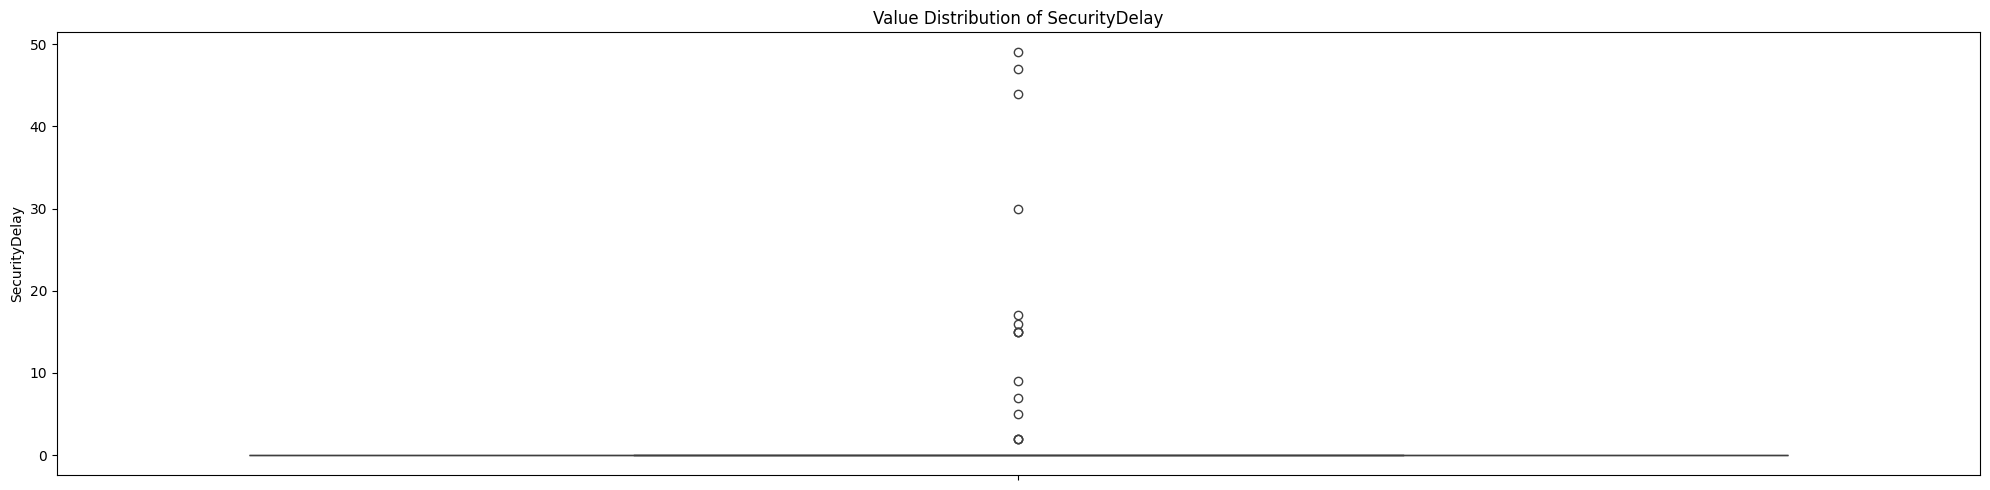

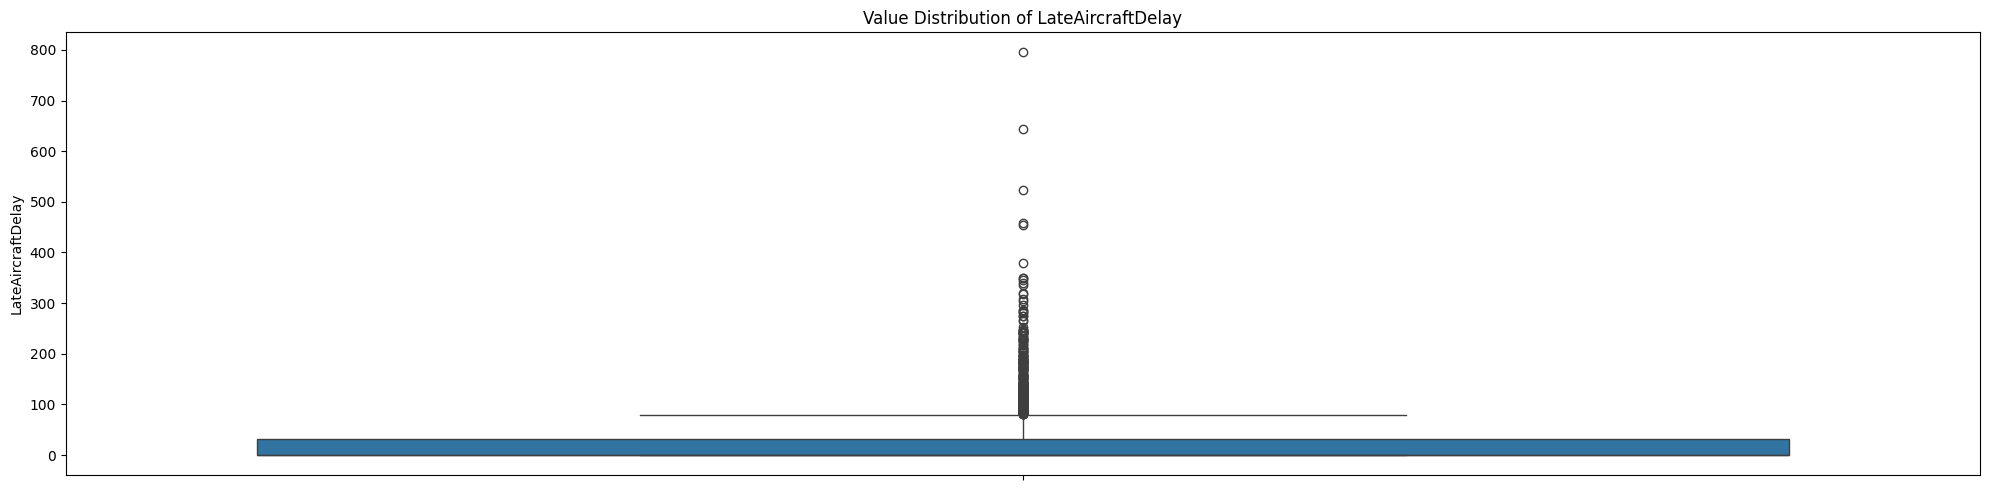

In [48]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

import matplotlib.pyplot as plt
import seaborn as sns

for column in df.columns:
    plt.figure(figsize=(20, 5))

    if df[column].dtype in ['int64', 'float64']:
        sns.boxplot(data=df, y=column)
        plt.title(f'Value Distribution of {column}')
    else:
        sns.countplot(data=df, x=column, order=df[column].value_counts().index[:20])
        # sns.countplot(data=df, x=column)
        plt.title(f'Value Distribution of {column}')
    plt.tight_layout()
    plt.show()

In [49]:
## 3.2 Calculate the missing value percentage of each column
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)) * 100

print("Missing Value Percentage:\n", missing_percentage, "%")

Missing Value Percentage:
 Year                  0.000
Month                 0.000
DayofMonth            0.000
DayOfWeek             0.000
UniqueCarrier         0.000
TailNum               0.245
FlightNum             0.000
Origin                0.000
Dest                  0.000
CRSDepTime            0.000
DepTime               1.780
DepDelay              1.780
TaxiOut               1.840
TaxiIn                1.880
CRSArrTime            0.000
ArrTime               1.880
ArrDelay              2.105
Cancelled             0.000
CancellationCode     98.150
Diverted              0.000
CRSElapsedTime        0.005
ActualElapsedTime     2.105
AirTime               2.105
Distance              0.000
CarrierDelay         81.565
WeatherDelay         81.565
NASDelay             81.565
SecurityDelay        81.565
LateAircraftDelay    81.565
dtype: float64 %


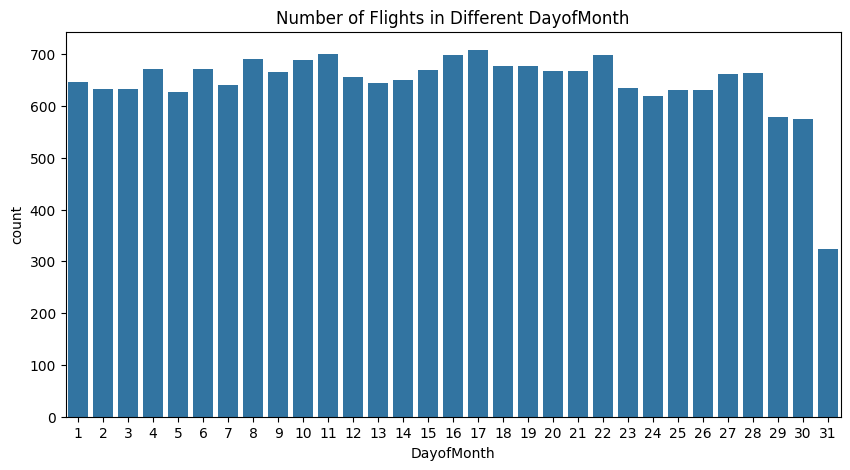

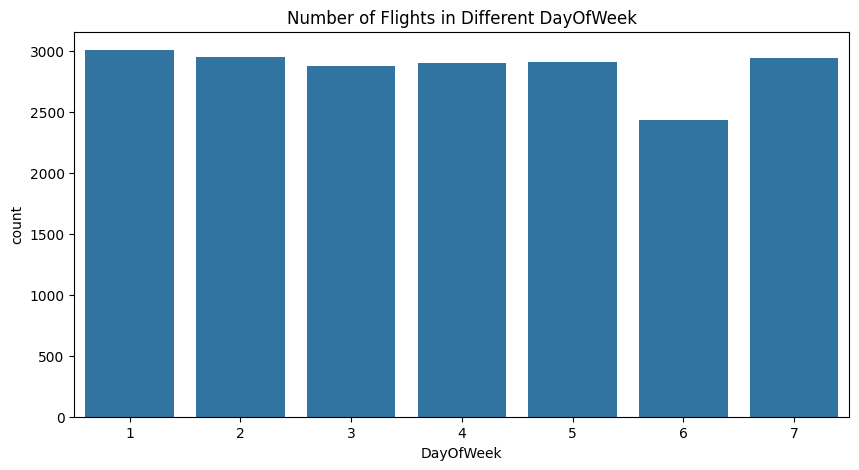

In [50]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek

## Visualize with Barchart
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='DayofMonth')
plt.title("Number of Flights in Different DayofMonth")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='DayOfWeek')
plt.title("Number of Flights in Different DayOfWeek")
plt.show()


Text(0, 0.5, 'Count')

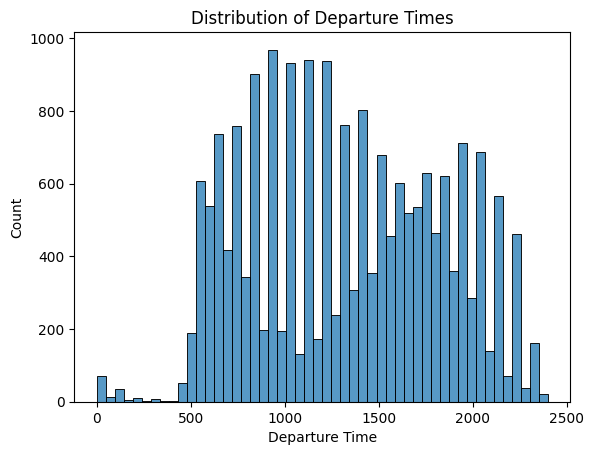

In [51]:
## 3.4.1 Histogram of Departure Time

sns.histplot(df['DepTime'].dropna(), bins=50)
plt.title('Distribution of Departure Times')
plt.xlabel('Departure Time')
plt.ylabel('Count')

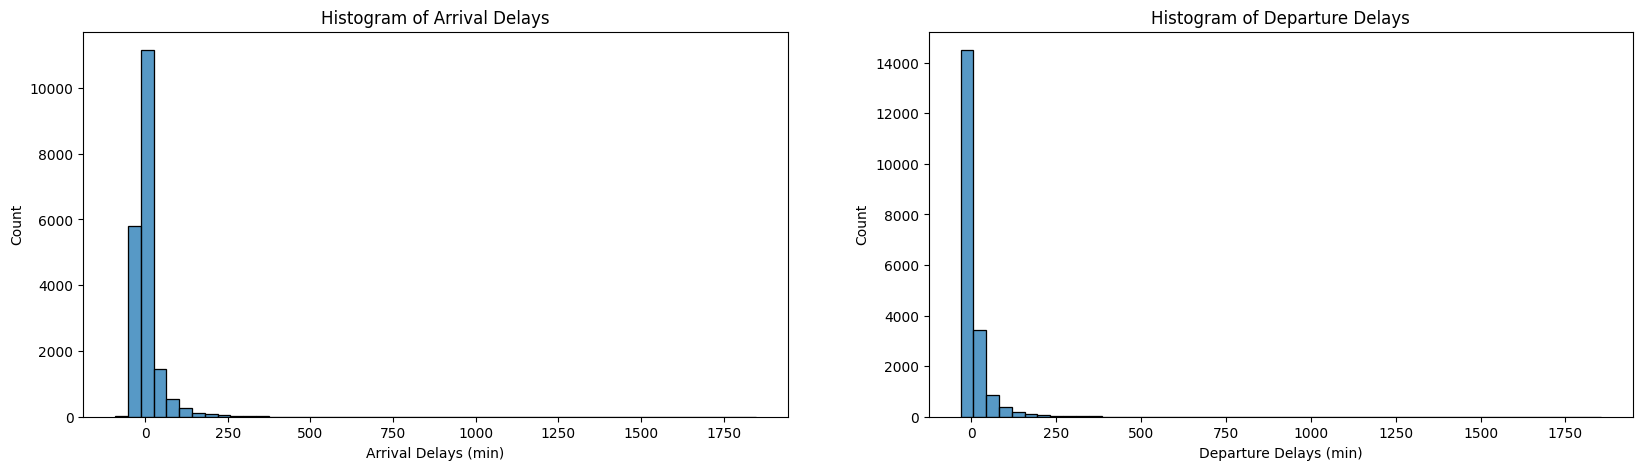

In [52]:
## 3.4.2 Histogram of arrival and departure delays

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.histplot(df['ArrDelay'].dropna(), bins=50, ax=axes[0])
axes[0].set_title('Histogram of Arrival Delays')
axes[0].set_xlabel('Arrival Delays (min)')
axes[0].set_ylabel('Count')

sns.histplot(df['DepDelay'].dropna(), bins=50, ax=axes[1])
axes[1].set_title('Histogram of Departure Delays')
axes[1].set_xlabel('Departure Delays (min)')
axes[1].set_ylabel('Count')

plt.show()

<Figure size 2000x1000 with 0 Axes>

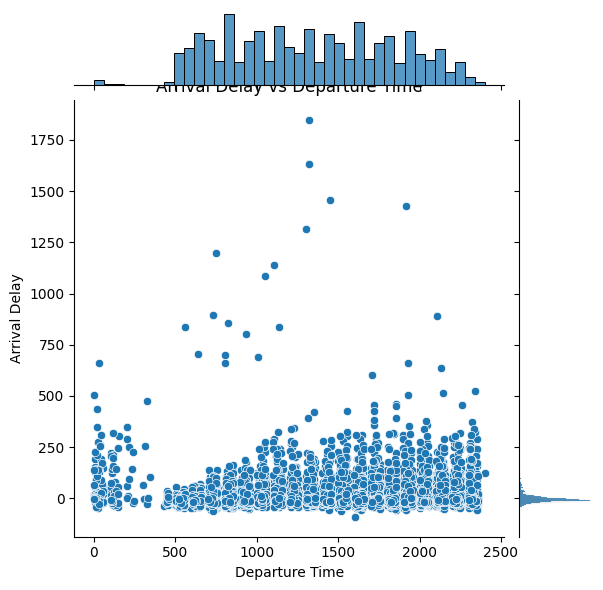

In [53]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot

plt.figure(figsize=(20, 10))

# sns.scatterplot(data=df, x='DepTime', y='ArrDelay')
sns.jointplot(x='DepTime', y='ArrDelay', data=df)
plt.title('Arrival Delay vs Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Arrival Delay')
plt.show()

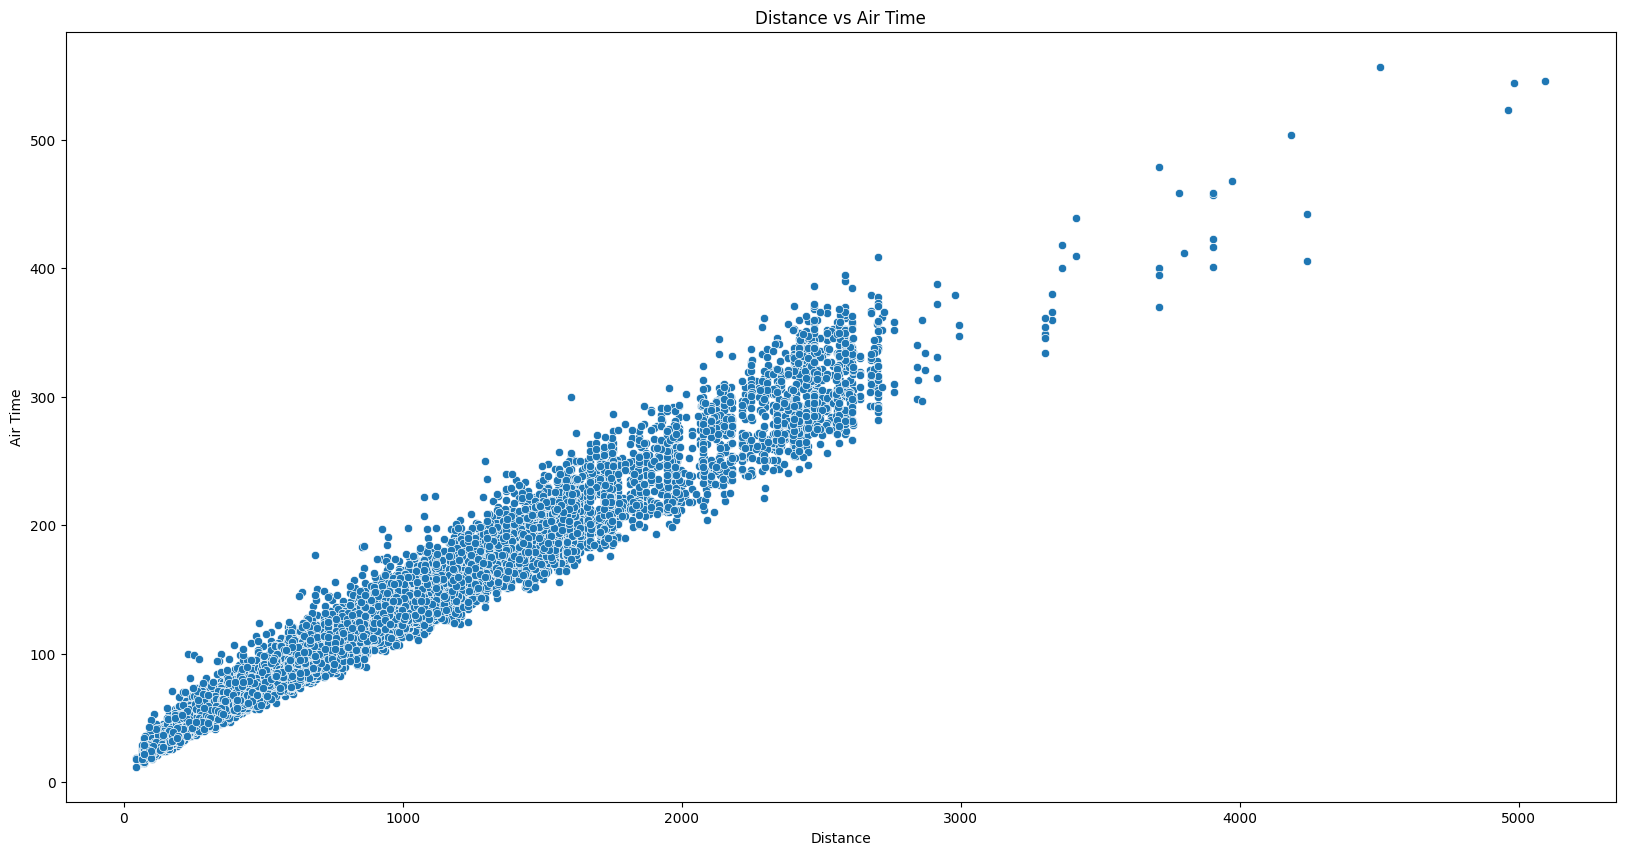

In [54]:
## 3.5.2 bivariate analysis: distance and airtimes

plt.figure(figsize=(20, 10))

sns.scatterplot(data=df, x='Distance', y='AirTime')
plt.title('Distance vs Air Time')
plt.xlabel('Distance')
plt.ylabel('Air Time')
plt.show()

### 4. Feature engineering and cleaning

In [55]:
## 4.1 creating a categorical column for weekday
## {      1: 'Monday',
##        2: 'Tuesday',
##        3: 'Wednesday',
##        4: 'Thursday',
##        5: 'Friday',
##        6: 'Saturday',
##        7: 'Sunday'}

weekdays = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

df['Weekday'] = df['DayOfWeek'].map(weekdays)

In [56]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)

df['ArrDelay_No_Negatives'] = df['ArrDelay'].apply(lambda x: max(0,x) if pd.notna(x) else x)
df['Log_ArrDelay'] = np.log1p(df['ArrDelay_No_Negatives'])

In [57]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75

df['DecimalDepTime'] = (df['CRSDepTime'] // 100) + (df['CRSDepTime'] % 100) / 60

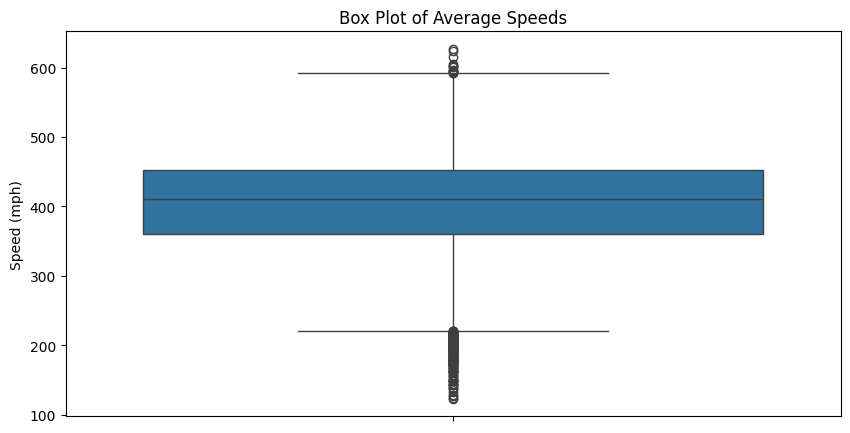

In [58]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)

df['speed'] = (df['Distance'] / df['AirTime']) * 60

## boxplots of average speeds
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, y='speed')
plt.title('Box Plot of Average Speeds')
plt.ylabel('Speed (mph)')
plt.show()

In [59]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.

flights_greater_650 = df[df['speed'] > 650]
proportion = len(flights_greater_650) / len(df)

print("Proportion of flights with speeds greater than 650 mph: ", proportion)

Proportion of flights with speeds greater than 650 mph:  0.0


### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [18]:
## Save transformed data
df.to_csv('final_airline_2019.csv', index=False)